# **Module 1 – Connect Python with MySQL**

# **Import Libraries**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector

plt.style.use("ggplot")

# **Connect to MySQL**

In [ ]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Dummy_password",
    database="food_delivery_analytics"
)

print("Connected Successfully")

Connected Successfully


### **Read Tables**

In [6]:
customers = pd.read_sql("SELECT * FROM customers", conn)
restaurants = pd.read_sql("SELECT * FROM restaurants", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
menu_items = pd.read_sql("SELECT * FROM menu_items", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\3446835238.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM customers", conn)
C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\3446835238.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  restaurants = pd.read_sql("SELECT * FROM restaurants", conn)
C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\3446835238.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", con

In [7]:
# Verifiying by printing the shape of the tables/dataframes

print("customers shape : ", customers.shape)
print("restaurants shape : ", restaurants.shape)
print("orders shape : ", orders.shape)
print("menu_items shape : ", menu_items.shape)
print("order_items shape : ", order_items.shape)


customers shape :  (1500, 3)
restaurants shape :  (120, 4)
orders shape :  (5000, 6)
menu_items shape :  (400, 3)
order_items shape :  (12391, 4)


# **Module 2: Data Exploration & Data Quality Checks**

### **1. Dataset Information**

In [8]:
datasets = {
    "Customers": customers,
    "Restaurants": restaurants,
    "Orders": orders,
    "Menu Items": menu_items,
    "Order Items": order_items
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print('='*50)
    print(df.info())


Customers
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  1500 non-null   str   
 1   city         1500 non-null   str   
 2   signup_date  1500 non-null   object
dtypes: object(1), str(2)
memory usage: 35.3+ KB
None

Restaurants
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   restaurant_id  120 non-null    str    
 1   cuisine        120 non-null    str    
 2   city           120 non-null    str    
 3   rating         120 non-null    float64
dtypes: float64(1), str(3)
memory usage: 3.9 KB
None

Orders
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   or

### **2. Missing Values**

In [9]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Customers
customer_id    0
city           0
signup_date    0
dtype: int64

Restaurants
restaurant_id    0
cuisine          0
city             0
rating           0
dtype: int64

Orders
order_id         0
customer_id      0
restaurant_id    0
order_time       0
delivery_time    0
status           0
dtype: int64

Menu Items
item_id          0
restaurant_id    0
price            0
dtype: int64

Order Items
order_id    0
item_id     0
quantity    0
price       0
dtype: int64


### **3. Duplicate Rows**

In [10]:
for name, df in datasets.items():
    print(f"{name} : {df.duplicated().sum()}")

Customers : 0
Restaurants : 0
Orders : 0
Menu Items : 0
Order Items : 0


### **4. Statistical Summary**

### Code Explanation

- **`for name, df in datasets.items():`** → loop through each dataset name and its dataframe
- **`print(f"\n{name}")`** → print a blank line then the dataset's name
- **`print(df.describe(include='all'))`** → print summary stats (count, mean, min, max, unique values, etc.) for all columns, both numeric and non-numeric

In [11]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.describe(include='all'))


Customers
       customer_id     city signup_date
count         1500     1500        1500
unique        1500        6         619
top          C0001  Bristol  2023-04-10
freq             1      270           8

Restaurants
       restaurant_id cuisine   city      rating
count            120     120    120  120.000000
unique           120       6      6         NaN
top             R001    Thai  Leeds         NaN
freq               1      26     25         NaN
mean             NaN     NaN    NaN    4.006667
std              NaN     NaN    NaN    0.595464
min              NaN     NaN    NaN    3.000000
25%              NaN     NaN    NaN    3.500000
50%              NaN     NaN    NaN    4.000000
75%              NaN     NaN    NaN    4.525000
max              NaN     NaN    NaN    5.000000

Orders
       order_id customer_id restaurant_id  order_time  \
count      5000        5000          5000        5000   
unique     5000        1452           120         501   
top      O00001      

### **5. First Five Rows**

### Code Explanation

- **`for name, df in datasets.items():`** → loop through each dataset name and its dataframe
- **`print(f"\n{name}")`** → print a blank line then the dataset's name
- **`display(df.head())`** → show the first 5 rows of the dataframe in a nicely formatted table

In [12]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.head())


Customers
  customer_id        city signup_date
0       C0001     Bristol  2022-04-25
1       C0002      London  2022-10-09
2       C0003  Manchester  2022-08-17
3       C0004  Manchester  2022-04-15
4       C0005     Bristol  2023-07-13

Restaurants
  restaurant_id   cuisine        city  rating
0          R001    Indian  Manchester     3.4
1          R002   Chinese       Leeds     4.1
2          R003   Chinese       Leeds     4.1
3          R004      Thai  Birmingham     3.5
4          R005  American     Bristol     4.3

Orders
  order_id customer_id restaurant_id  order_time       delivery_time  \
0   O00001       C1234          R041  2023-01-17 2023-01-17 00:43:00   
1   O00002       C1017          R019  2023-04-24 2023-04-24 00:33:00   
2   O00003       C0488          R045  2024-01-17 2024-01-17 00:29:00   
3   O00004       C1452          R086  2023-03-27 2023-03-27 00:31:00   
4   O00005       C0915          R002  2024-01-09 2024-01-09 01:02:00   

      status  
0       Late  
1

# **Module 3 - Visualization**

### Q. Which cuisine generates the highest revenue?

In [13]:
plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 150

### **Step 1 – Prepare the Data**

In [14]:
query = """
SELECT 
    r.cuisine,
    ROUND(SUM(oi.quantity * oi.price),2) AS revenue
FROM restaurants r
JOIN orders o
    ON r.restaurant_id = o.restaurant_id
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY 
	r.cuisine
ORDER BY    
    revenue DESC;
"""

cuisine_revenue = pd.read_sql(query, conn)
cuisine_revenue

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\249488312.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cuisine_revenue = pd.read_sql(query, conn)


,cuisine,revenue
0,Thai,127428.71
1,Indian,102630.54
2,American,90864.14
3,Mexican,90060.25
4,Italian,89963.60
5,Chinese,59561.91


### **Step 2 – Plot the Chart**

### Q. 1 Which cuisine generates the highest revenue?
### Code Explanation

- **`plt.figure(figsize=(10,6))`** → create a new figure with width 10 and height 6
- **`plt.bar(cuisine_revenue["cuisine"], cuisine_revenue["revenue"])`** → draw a bar chart with cuisine names on x-axis and revenue on y-axis
- **`plt.title("Revenue by Cuisine", fontsize=16)`** → set the chart title with font size 16
- **`plt.xlabel("Cuisine")`** → label the x-axis as "Cuisine"
- **`plt.ylabel("Revenue (₹)")`** → label the y-axis as "Revenue (₹)"
- **`plt.xticks(rotation=20)`** → rotate x-axis labels by 20 degrees for better readability
- **`plt.tight_layout()`** → adjust spacing so labels/titles don't overlap or get cut off
- **`plt.show()`** → display the final chart

In [15]:
# Common for all of the charts

from pathlib import Path
output_dir = Path("Images")
output_dir.mkdir(exist_ok=True)

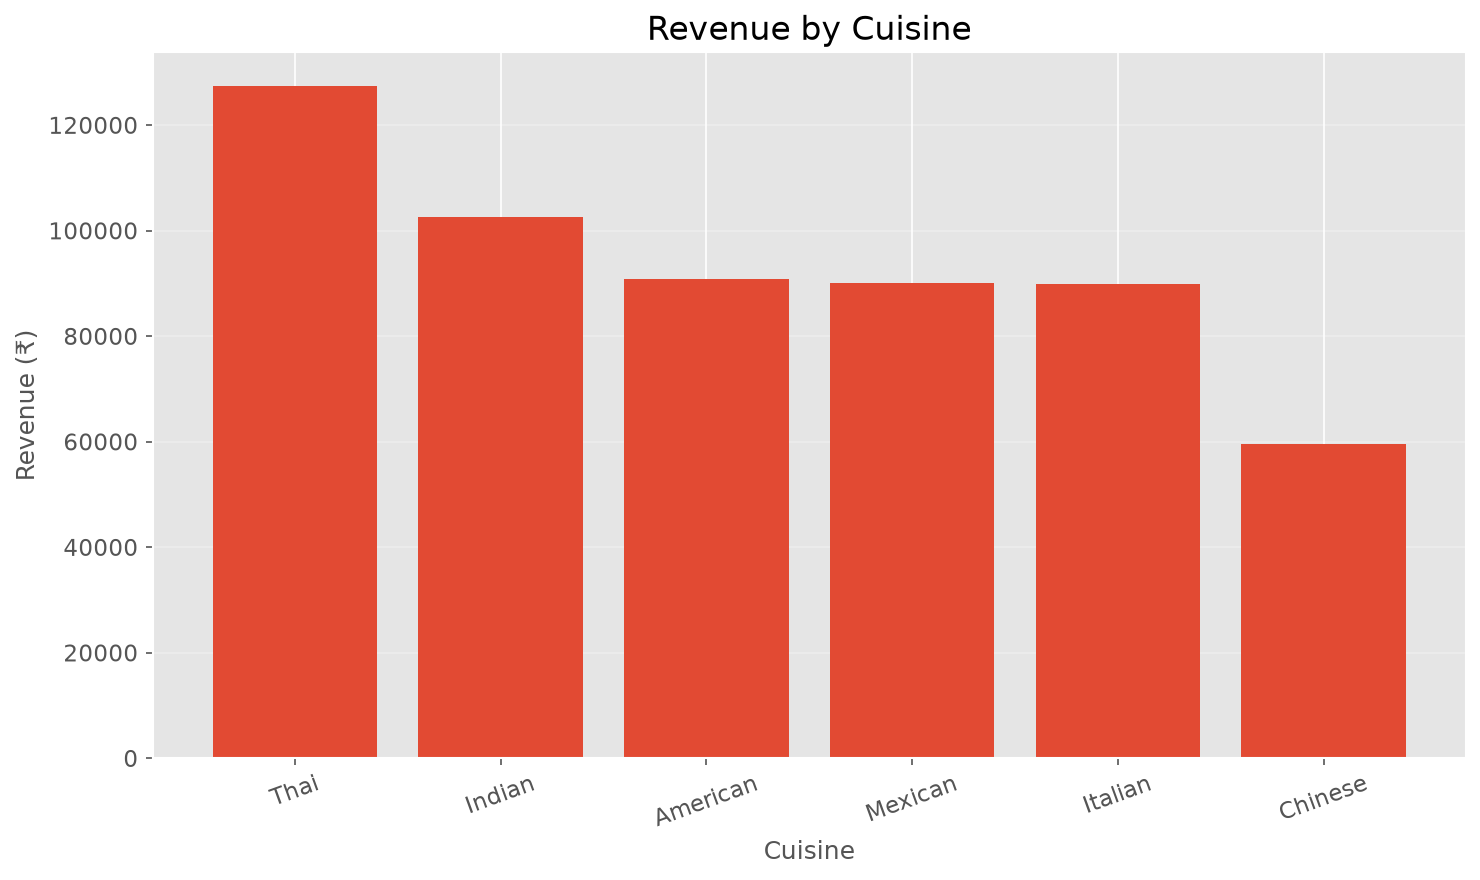

In [16]:
plt.figure(figsize=(10,6))

plt.bar(
    cuisine_revenue["cuisine"],
    cuisine_revenue["revenue"]
)

plt.title("Revenue by Cuisine", fontsize=16)
plt.xlabel("Cuisine")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=20)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_dir / "Revenue_by_Cuisine.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Q. 2 Which restaurants generate the highest revenue?

In [17]:
query = """
SELECT
	r.restaurant_id,
    ROUND(SUM( quantity * price),2) AS revenue
FROM restaurants r
JOIN orders o
	ON r.restaurant_id = o.restaurant_id
JOIN order_items oi
	ON o.order_id = oi.order_id
GROUP BY 
	r.restaurant_id 
ORDER BY revenue DESC
LIMIT 10;
"""

top_restaurants = pd.read_sql(query, conn)
top_restaurants

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\346897724.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_restaurants = pd.read_sql(query, conn)


,restaurant_id,revenue
0,R061,6908.29
1,R073,6817.47
2,R022,6754.09
3,R088,6753.98
4,R096,6099.41
5,R060,6059.29
6,R115,6045.79
7,R074,5968.25
8,R078,5944.74
9,R090,5921.60


### Code Explanation

- **`plt.figure(figsize=(12,6))`** → create a new figure with width 12 and height 6
- **`plt.bar(top_restaurants["restaurant_id"], top_restaurants["revenue"])`** → draw a bar chart with restaurant IDs on x-axis and revenue on y-axis
- **`plt.title("Top 10 Restaurants by Revenue", fontsize=16)`** → set the chart title with font size 16
- **`plt.xlabel("Restaurant")`** → label the x-axis as "Restaurant"
- **`plt.ylabel("Revenue (₹)")`** → label the y-axis as "Revenue (₹)"
- **`plt.tight_layout()`** → adjust spacing so labels/titles don't overlap or get cut off
- **`plt.show()`** → display the final chart

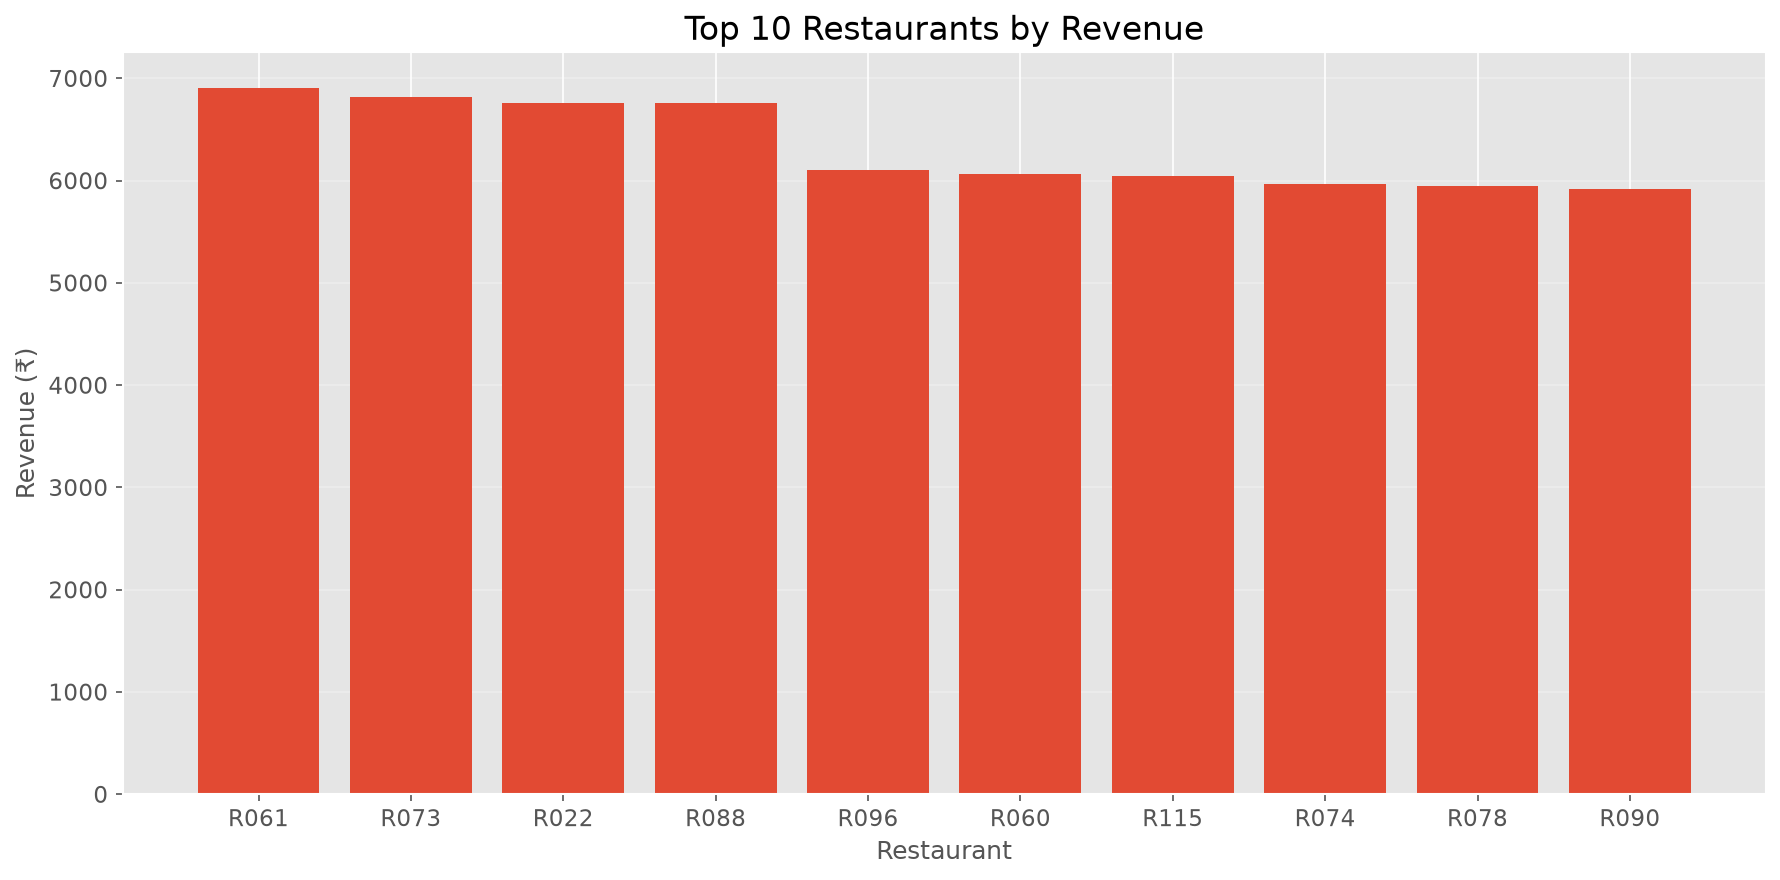

In [18]:
plt.figure(figsize=(12,6))

plt.bar(
    top_restaurants["restaurant_id"],
    top_restaurants["revenue"]
)

plt.title("Top 10 Restaurants by Revenue", fontsize=16)
plt.xlabel("Restaurant")
plt.ylabel("Revenue (₹)")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_dir / "Top_10_Restaurants_by_Revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Q. 3 How is customer spending distributed?

In [19]:
query = """
SELECT
	c.customer_id,
    ROUND(SUM( quantity * price), 2) AS total_spent
FROM customers c
JOIN orders o
	ON c.customer_id = o.customer_id
JOIN order_items oi
	ON o.order_id = oi.order_id
GROUP BY
	c.customer_id;
"""

customer_spend = pd.read_sql(query, conn)
customer_spend

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\2060929481.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_spend = pd.read_sql(query, conn)


,customer_id,total_spent
0,C0001,711.37
1,C0002,624.89
2,C0003,608.09
3,C0004,23.14
4,C0005,332.32
...,...,...
1447,C1496,225.00
1448,C1497,569.62
1449,C1498,110.33
1450,C1499,1075.29


### Code Explanation

- **`plt.figure(figsize=(10,6))`** → create a new figure with width 10 and height 6
- **`plt.hist(customer_spend["total_spent"], bins=25)`** → draw a histogram of total spending, grouped into 25 bins
- **`plt.title("Customer Spending Distribution", fontsize=16)`** → set the chart title with font size 16
- **`plt.xlabel("Total Spending (₹)")`** → label the x-axis as "Total Spending (₹)"
- **`plt.ylabel("Number of Customers")`** → label the y-axis as "Number of Customers"
- **`plt.tight_layout()`** → adjust spacing so labels/titles don't overlap or get cut off
- **`plt.show()`** → display the final chart

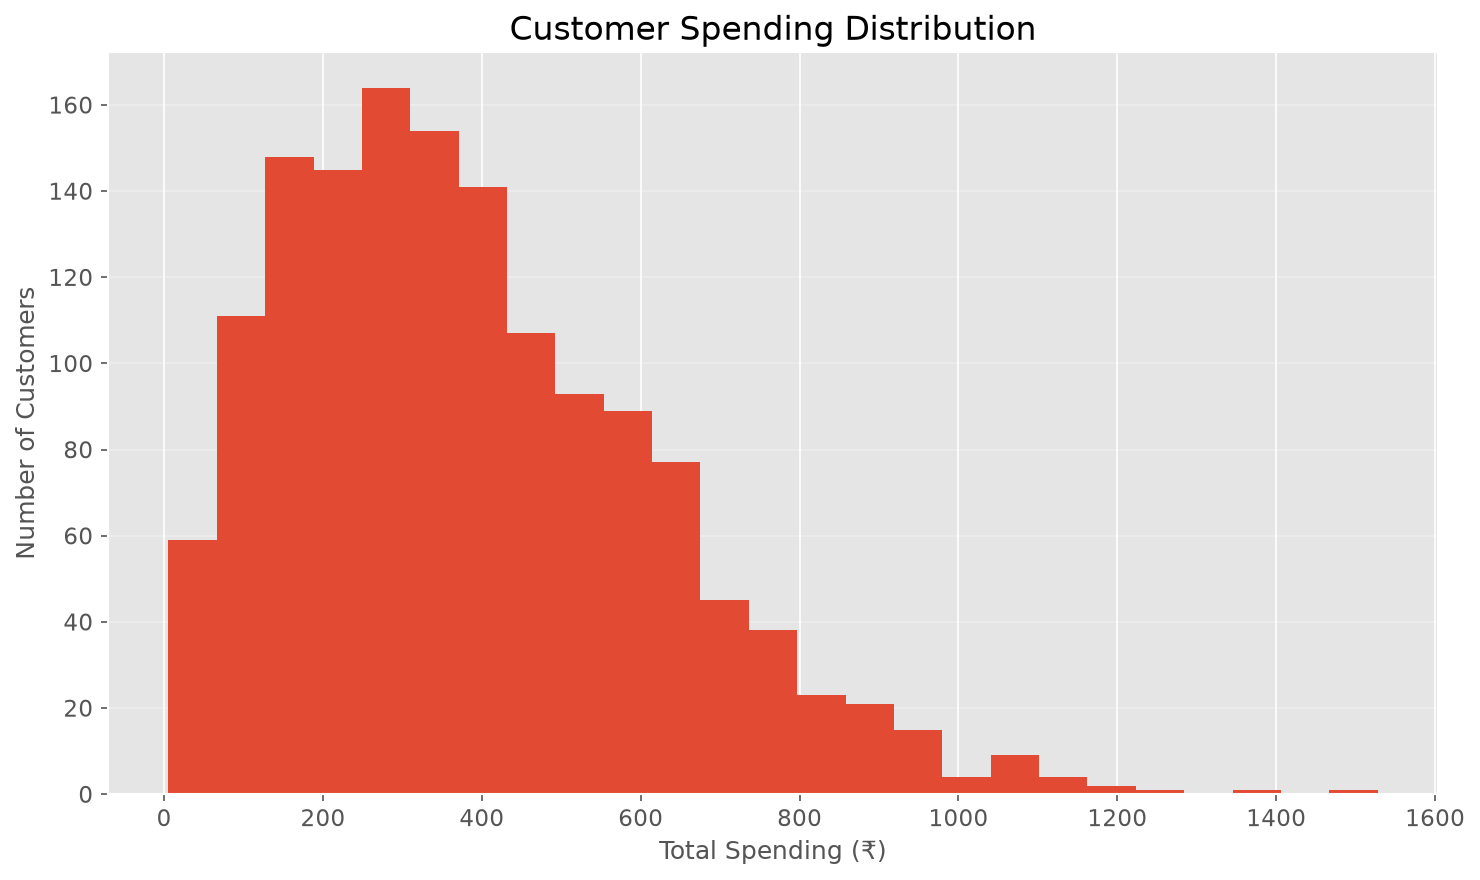

In [20]:
plt.figure(figsize=(10,6))

plt.hist(customer_spend["total_spent"], bins=25)
plt.title("Customer Spending Distribution", fontsize=16)
plt.xlabel("Total Spending (₹)")
plt.ylabel("Number of Customers")


plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_dir / "Customer_Spending_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Q. 4 Order Status Distribution

In [21]:
query = """
SELECT 
	status,
    COUNT(*) AS total_orders
FROM orders o
GROUP BY status
ORDER BY total_orders DESC;
"""

order_status = pd.read_sql(query, conn)
order_status

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\610372164.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_status = pd.read_sql(query, conn)


,status,total_orders
0,Delivered,1717
1,Late,1671
2,Cancelled,1612


### Code Explanation

- **`plt.figure(figsize=(8, 5))`** → create a new figure with width 8 and height 5
- **`bars = plt.bar(order_status["status"], order_status["total_orders"])`** → draw a bar chart with order status on x-axis, order count on y-axis, and save the bars for later use
- **`plt.title("Order Status Distribution")`** → set the chart title
- **`plt.xlabel("Order Status")`** → label the x-axis as "Order Status"
- **`plt.ylabel("Number of Orders")`** → label the y-axis as "Number of Orders"
- **`for bar in bars:`** → loop through each bar in the chart
- **`plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(bar.get_height()):,}", ha="center", va="bottom")`** → write the exact number on top of each bar, centered horizontally
- **`plt.tight_layout()`** → adjust spacing so labels/titles don't overlap or get cut off
- **`plt.savefig("../Images/order_status_distribution.png", dpi=300, bbox_inches="tight")`** → save the chart as a PNG image with high resolution and no extra whitespace
- **`plt.show()`** → display the final chart

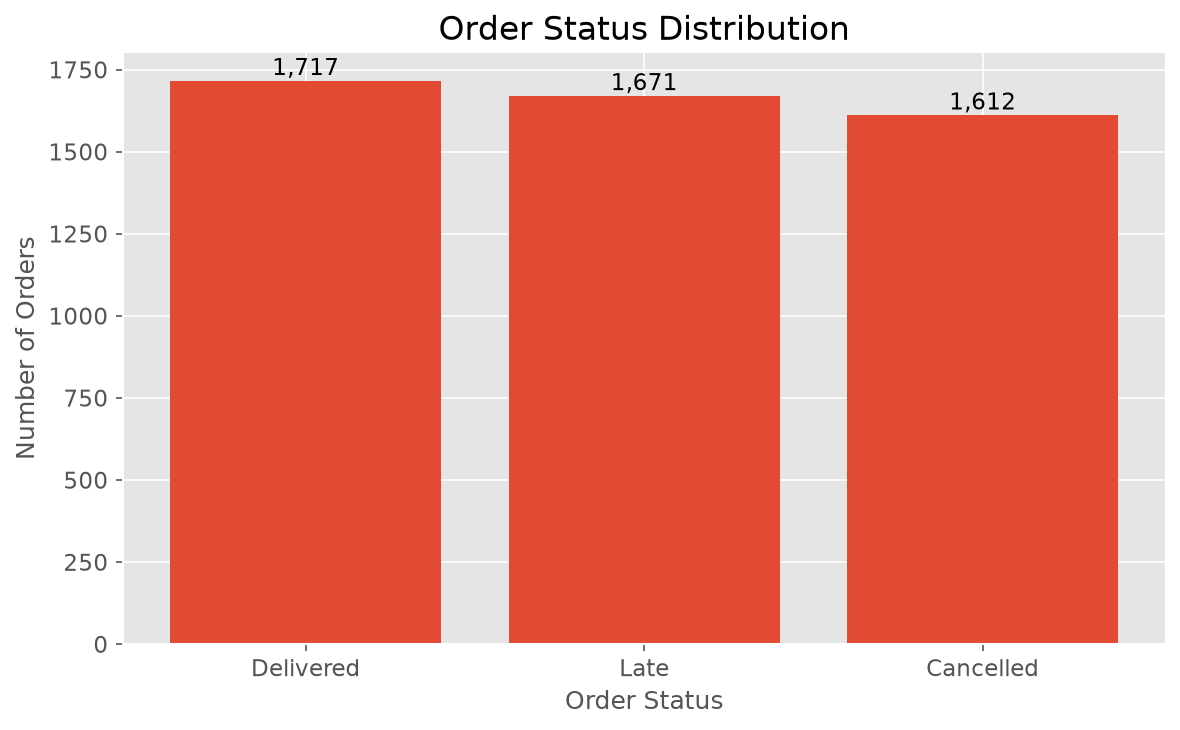

In [22]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    order_status["status"],
    order_status["total_orders"]
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")


for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig( 
    output_dir / " Order_status_Distribution.png", 
    dpi=300, 
    bbox_inches="tight")
plt.show()

### 5. Monthly Revenue Trend

In [23]:
query = """
SELECT
	DATE_FORMAT(o.order_time, '%Y-%m') AS month,
    ROUND(SUM(oi.quantity * oi.price), 2) AS revenue
FROM orders o
JOIN order_items oi
	ON o.order_id = oi.order_id
GROUP BY  DATE_FORMAT(o.order_time, '%Y-%m')
ORDER BY month;
"""

monthly_revenue = pd.read_sql(query, conn)
monthly_revenue

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\2576476519.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_revenue = pd.read_sql(query, conn)


,month,revenue
0,2023-01,33453.28
1,2023-02,30887.60
2,2023-03,35970.92
3,2023-04,36117.04
4,2023-05,33419.53
5,2023-06,33902.61
6,2023-07,36348.99
7,2023-08,35212.25
8,2023-09,34827.77
9,2023-10,36159.31


### Code Explanation

- **`plt.figure(figsize=(11, 6))`** → create a new figure with width 11 and height 6
- **`plt.plot(monthly_revenue["month"], monthly_revenue["revenue"], marker="o")`** → draw a line chart of revenue over months, with circular markers on each data point
- **`plt.title("Monthly Revenue Trend")`** → set the chart title
- **`plt.xlabel("Month")`** → label the x-axis as "Month"
- **`plt.ylabel("Revenue (₹)")`** → label the y-axis as "Revenue (₹)"
- **`plt.xticks(rotation=45)`** → rotate x-axis labels by 45 degrees for better readability
- **`plt.grid(alpha=0.3)`** → add a light gridline (30% opacity) for easier reading
- **`plt.tight_layout()`** → adjust spacing so labels/titles don't overlap or get cut off
- **`plt.savefig("../Images/monthly_revenue_trend.png", dpi=300, bbox_inches="tight")`** → save the chart as a PNG image with high resolution and no extra whitespace
- **`plt.show()`** → display the final chart

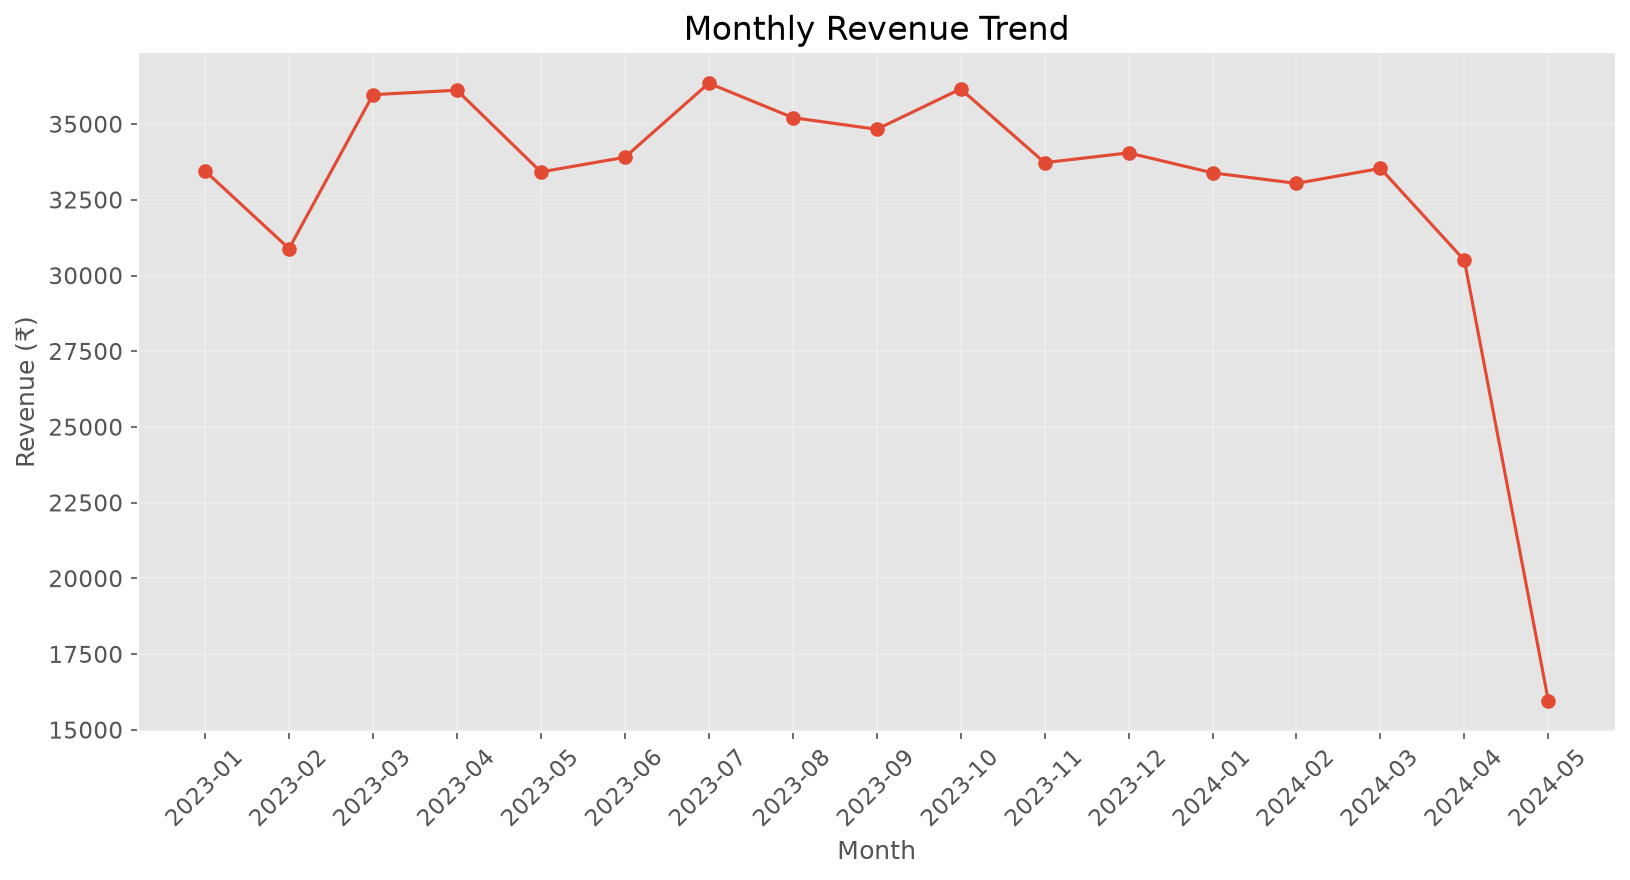

In [24]:
plt.figure(figsize=(11, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker = "o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    output_dir / "monthly_revenue_trend.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

### Q. 6 Average Rating by Cuisine

In [25]:
query = """
SELECT 
    cuisine,
    ROUND(AVG(rating), 2) AS average_rating
FROM restaurants
GROUP BY cuisine
ORDER BY average_rating DESC;
"""

cuisine_rating = pd.read_sql(query, conn)
cuisine_rating

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\2602405374.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cuisine_rating = pd.read_sql(query, conn)


,cuisine,average_rating
0,Mexican,4.20
1,Chinese,4.04
2,Italian,4.00
3,American,3.99
4,Thai,3.93
5,Indian,3.92


### Code Explanation

- **`plt.figure(figsize=(9, 6))`** → create a new figure with width 9 and height 6
- **`bars = plt.bar(cuisine_rating["cuisine"], cuisine_rating["average_rating"])`** → draw a bar chart with cuisine on x-axis, average rating on y-axis, and save the bars for later use
- **`plt.title("Average Restaurant Rating by Cuisine")`** → set the chart title
- **`plt.xlabel("Cuisine")`** → label the x-axis as "Cuisine"
- **`plt.ylabel("Average Rating")`** → label the y-axis as "Average Rating"
- **`plt.ylim(0, 5)`** → set the y-axis range from 0 to 5 (rating scale)
- **`plt.xticks(rotation=20)`** → rotate x-axis labels by 20 degrees for better readability
- **`for bar in bars:`** → loop through each bar in the chart
- **`plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{bar.get_height():.2f}", ha="center", va="bottom")`** → write the rating value (rounded to 2 decimals) on top of each bar, centered horizontally
- **`plt.tight_layout()`** → adjust spacing so labels/titles don't overlap or get cut off
- **`plt.savefig("../Images/average_rating_by_cuisine.png", dpi=300, bbox_inches="tight")`** → save the chart as a PNG image with high resolution and no extra whitespace
- **`plt.show()`** → display the final chart

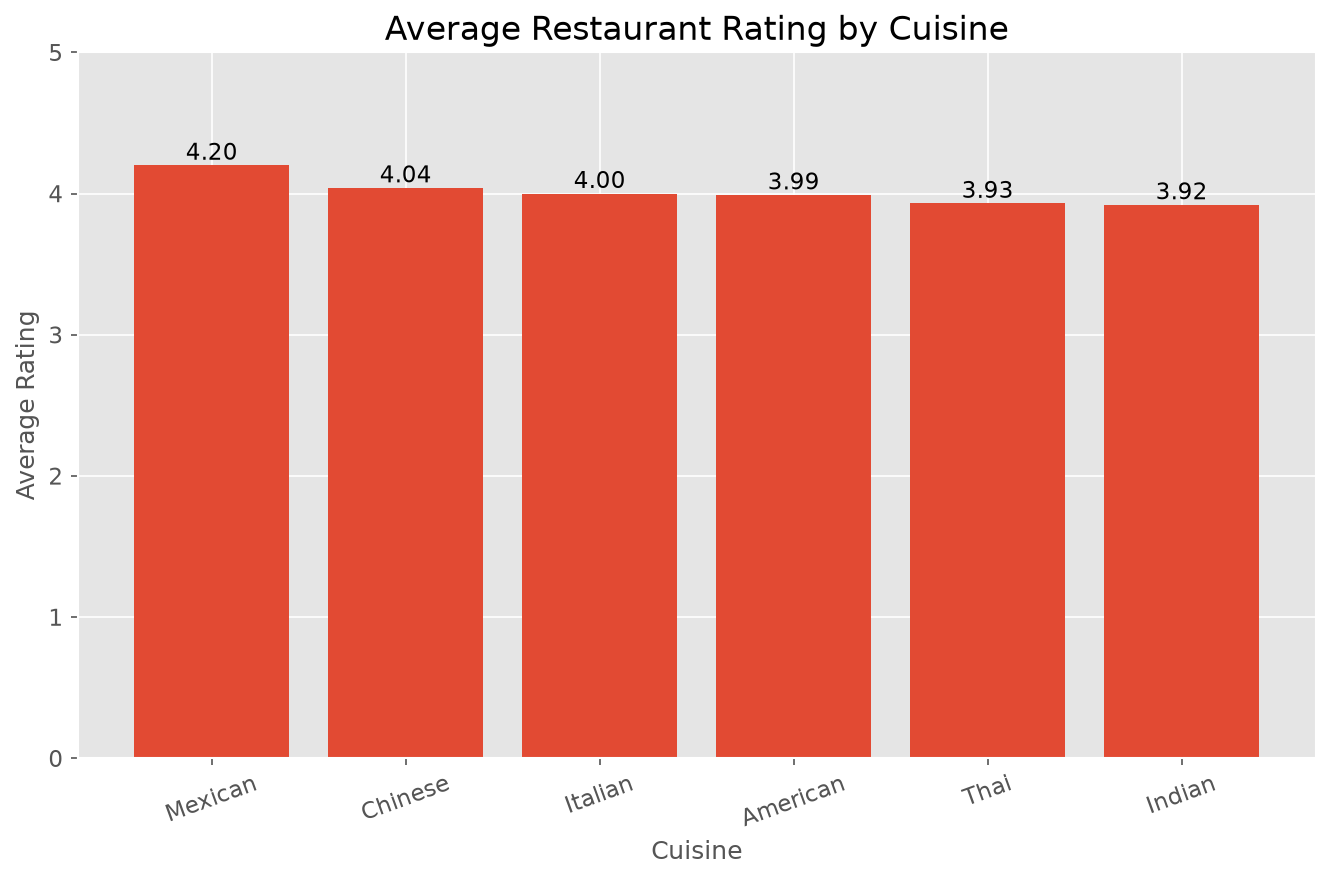

In [26]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    cuisine_rating["cuisine"],
    cuisine_rating["average_rating"]
)

plt.title("Average Restaurant Rating by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation = 20)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha = "center",
        va = "bottom"
    )

plt.tight_layout()
plt.savefig(
    output_dir / "average_rating_by_cuisine.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

### Q. 7 Which cuisine contributes the largest share of total revenue?
Revenue Contribution by Cuisine (%)

In [27]:
query = """
SELECT
    r.cuisine,
    ROUND(SUM(oi.quantity * oi.price), 2) AS revenue
FROM restaurants r
JOIN orders o
    ON r.restaurant_id = o.restaurant_id
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY r.cuisine
ORDER BY revenue DESC;
"""

revenue_share = pd.read_sql(query, conn)
revenue_share

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\3429532977.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  revenue_share = pd.read_sql(query, conn)


,cuisine,revenue
0,Thai,127428.71
1,Indian,102630.54
2,American,90864.14
3,Mexican,90060.25
4,Italian,89963.60
5,Chinese,59561.91


### Code Explanation

- **`plt.figure(figsize=(8,8))`** → create a new figure with width 8 and height 8 (square shape, good for pie charts)
- **`plt.pie(revenue_share["revenue"], labels=revenue_share["cuisine"], autopct="%1.1f%%", startangle=90)`** → draw a pie chart of revenue by cuisine, label each slice with the cuisine name, show percentage on each slice (1 decimal place), and start the first slice at 90 degrees
- **`plt.title("Revenue Contribution by Cuisine")`** → set the chart title
- **`plt.tight_layout()`** → adjust spacing so labels/titles don't overlap or get cut off
- **`plt.savefig("../Images/revenue_share_by_cuisine.png", dpi=300, bbox_inches="tight")`** → save the chart as a PNG image with high resolution and no extra whitespace
- **`plt.show()`** → display the final chart

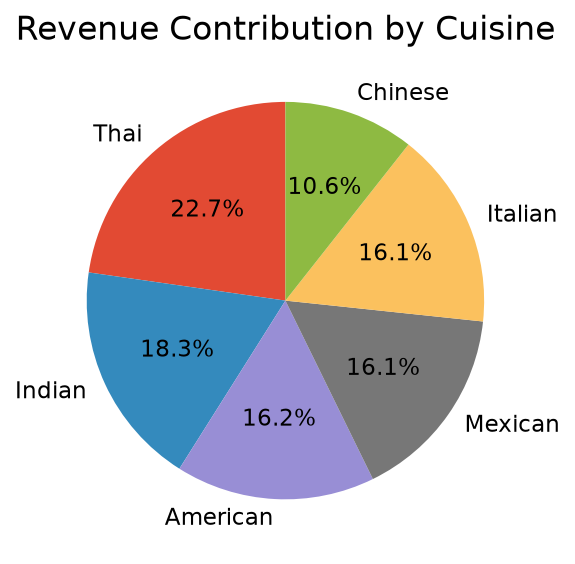

In [28]:
plt.figure(figsize=(4,4))

plt.pie(
    revenue_share["revenue"],
    labels=revenue_share["cuisine"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Contribution by Cuisine")

plt.tight_layout()
plt.savefig(
    output_dir / "revenue_share_by_cuisine.png",
    dpi = 300,
    bbox_inches="tight"
)

plt.show()

### Q. 8 Who are the highest-value customers?

Top Customers (Horizontal Bar)

In [29]:
query = """
SELECT 
    c.customer_id,
    ROUND(SUM(oi.quantity * oi.price), 2) AS total_spent
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY
    c.customer_id
ORDER BY 
    total_spent DESC
LIMIT 10;    
"""

top_customers = pd.read_sql(query, conn)
top_customers

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\3724765818.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_customers = pd.read_sql(query, conn)


,customer_id,total_spent
0,C1447,1527.70
1,C1065,1399.37
2,C1017,1272.65
3,C1176,1175.32
4,C1281,1169.58
5,C1179,1145.86
6,C1166,1128.45
7,C1215,1124.42
8,C0482,1104.36
9,C0860,1085.66


### Code Explanation

- **`plt.figure(figsize=(10,6))`** → create a new figure with width 10 and height 6
- **`plt.barh(top_customers["customer_id"], top_customers["total_spent"])`** → draw a horizontal bar chart with customer IDs on y-axis and total spending on x-axis
- **`plt.title("Top 10 Customers by Spending")`** → set the chart title
- **`plt.xlabel("Total Spending (₹)")`** → label the x-axis as "Total Spending (₹)"
- **`plt.ylabel("Customer ID")`** → label the y-axis as "Customer ID"
- **`plt.gca().invert_yaxis()`** → flip the y-axis so the top customer appears at the top instead of the bottom
- **`plt.tight_layout()`** → adjust spacing so labels/titles don't overlap or get cut off
- **`plt.savefig("../Images/top_customers.png", dpi=300, bbox_inches="tight")`** → save the chart as a PNG image with high resolution and no extra whitespace
- **`plt.show()`** → display the final chart

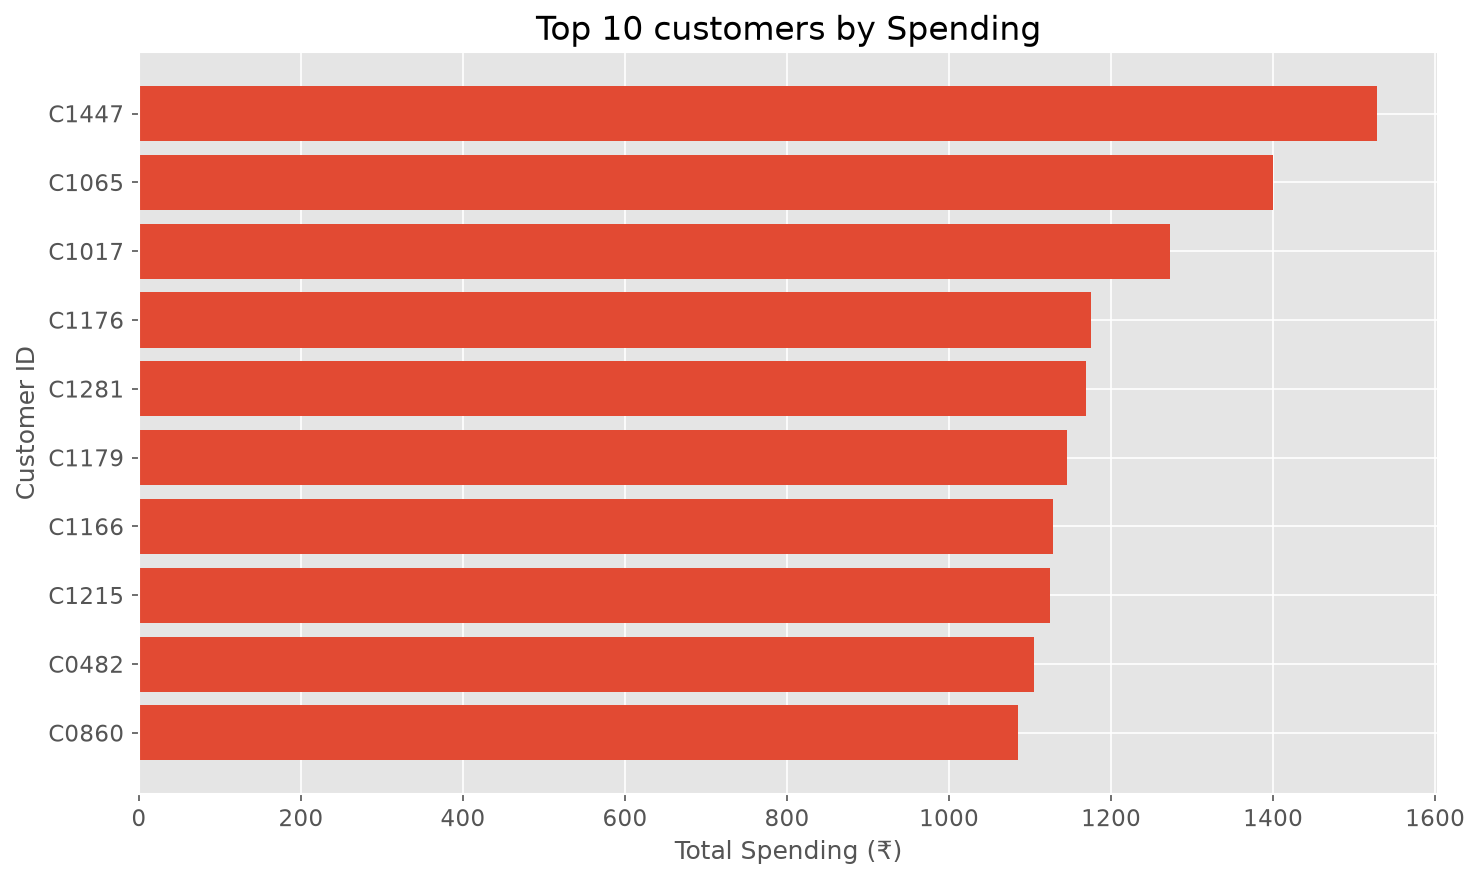

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["customer_id"],
    top_customers["total_spent"]
)

plt.title("Top 10 customers by Spending")
plt.xlabel("Total Spending (₹)")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    output_dir / "top_customers.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()


### Q. 9 Which weekday generates the highest revenue?
Revenue by Day of Week


In [31]:
query = """
SELECT
    DAYNAME(o.order_time) AS day_name,
    ROUND(SUM(oi.quantity * oi.price), 2) AS revenue
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY DAYNAME(o.order_time)
ORDER BY FIELD(
    day_name,
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
);
"""

weekday_revenue = pd.read_sql(query, conn)
weekday_revenue

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\1859592074.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  weekday_revenue = pd.read_sql(query, conn)


,day_name,revenue
0,Monday,76734.96
1,Tuesday,85092.44
2,Wednesday,76215.50
3,Thursday,78959.57
4,Friday,75914.84
5,Saturday,84290.23
6,Sunday,83301.61


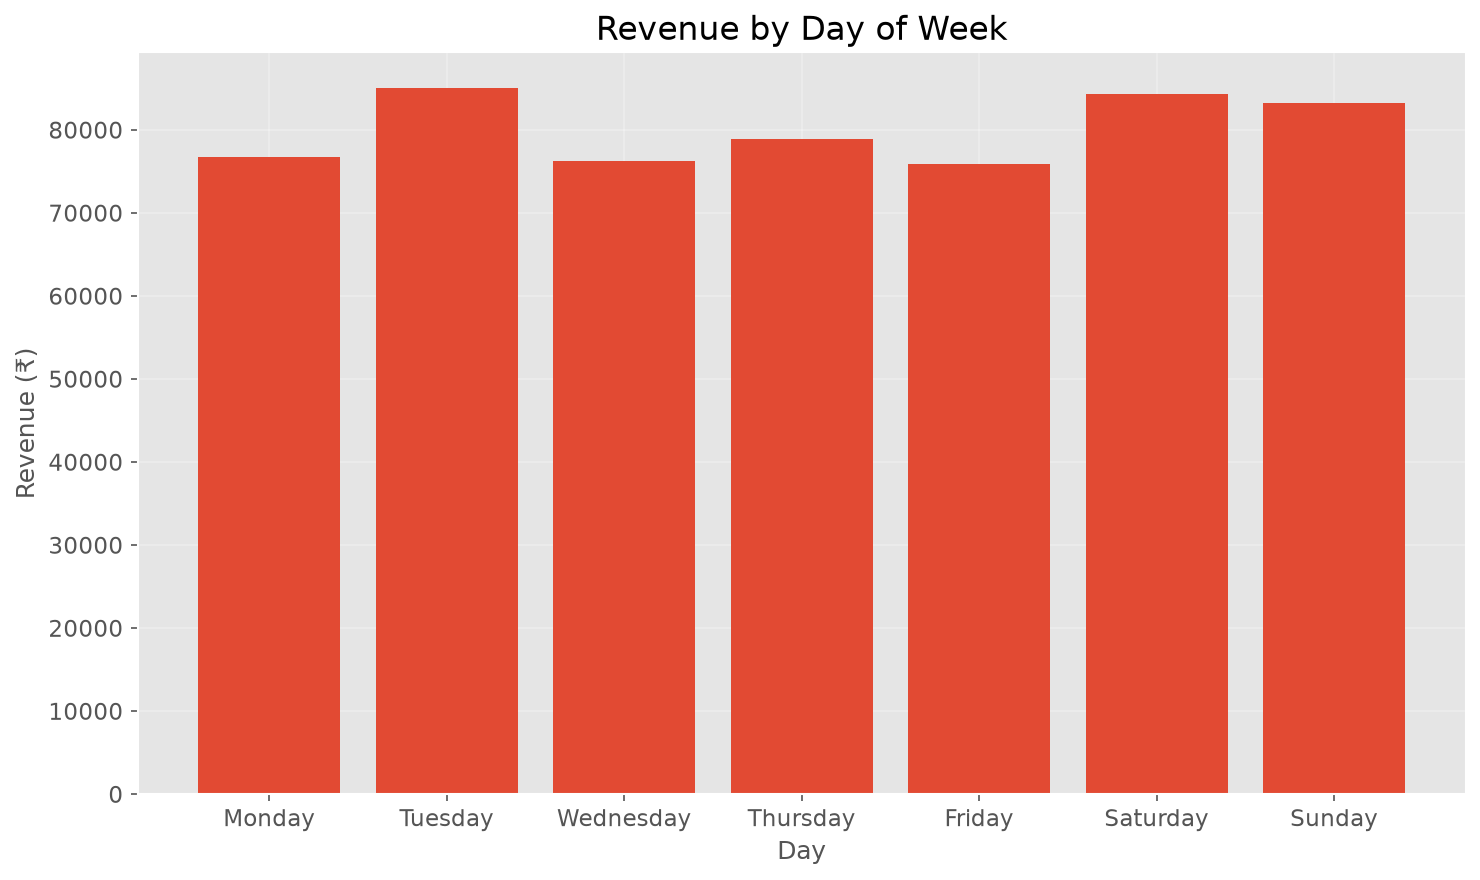

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    weekday_revenue["day_name"],
    weekday_revenue["revenue"]
    ##marker = "o"
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (₹)")
plt.grid(alpha = .3)
plt.tight_layout()

plt.savefig(
    output_dir / "revenue_by_weekday.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

### Q. 10 Do highly rated restaurants earn higher revenue?

Restaurant Rating vs Revenue

In [33]:
query = """
SELECT 
    r.restaurant_id,
    r.rating,
    ROUND(SUM(oi.quantity * oi.price), 2) AS revenue
FROM restaurants r 
JOIN orders o
    ON r.restaurant_id = o.restaurant_id
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY 
    r.restaurant_id,
    r.rating
"""

rating_vs_revenue = pd.read_sql(query, conn)
rating_vs_revenue

C:\Users\Rishiik Barri\AppData\Local\Temp\ipykernel_32700\2869447484.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rating_vs_revenue = pd.read_sql(query, conn)


,restaurant_id,rating,revenue
0,R001,3.4,3893.31
1,R002,4.1,3742.61
2,R003,4.1,5446.92
3,R004,3.5,5056.87
4,R005,4.3,2994.47
...,...,...,...
115,R116,3.6,4194.29
116,R117,4.7,3389.85
117,R118,3.7,4196.98
118,R119,4.6,4440.08


### Code Explanation

- **`plt.figure(figsize=(10,6))`** → create a new figure with width 10 and height 6
- **`plt.scatter(rating_vs_revenue["rating"], rating_vs_revenue["revenue"])`** → draw a scatter plot with rating on x-axis and revenue on y-axis
- **`plt.title("Restaurant Rating vs Revenue")`** → set the chart title
- **`plt.xlabel("Restaurant Rating")`** → label the x-axis as "Restaurant Rating"
- **`plt.ylabel("Revenue (₹)")`** → label the y-axis as "Revenue (₹)"
- **`plt.grid(alpha=.3)`** → add a light gridline (30% opacity) for easier reading
- **`plt.tight_layout()`** → adjust spacing so labels/titles don't overlap or get cut off
- **`plt.savefig("../Images/rating_vs_revenue.png", dpi=300, bbox_inches="tight")`** → save the chart as a PNG image with high resolution and no extra whitespace
- **`plt.show()`** → display the final chart

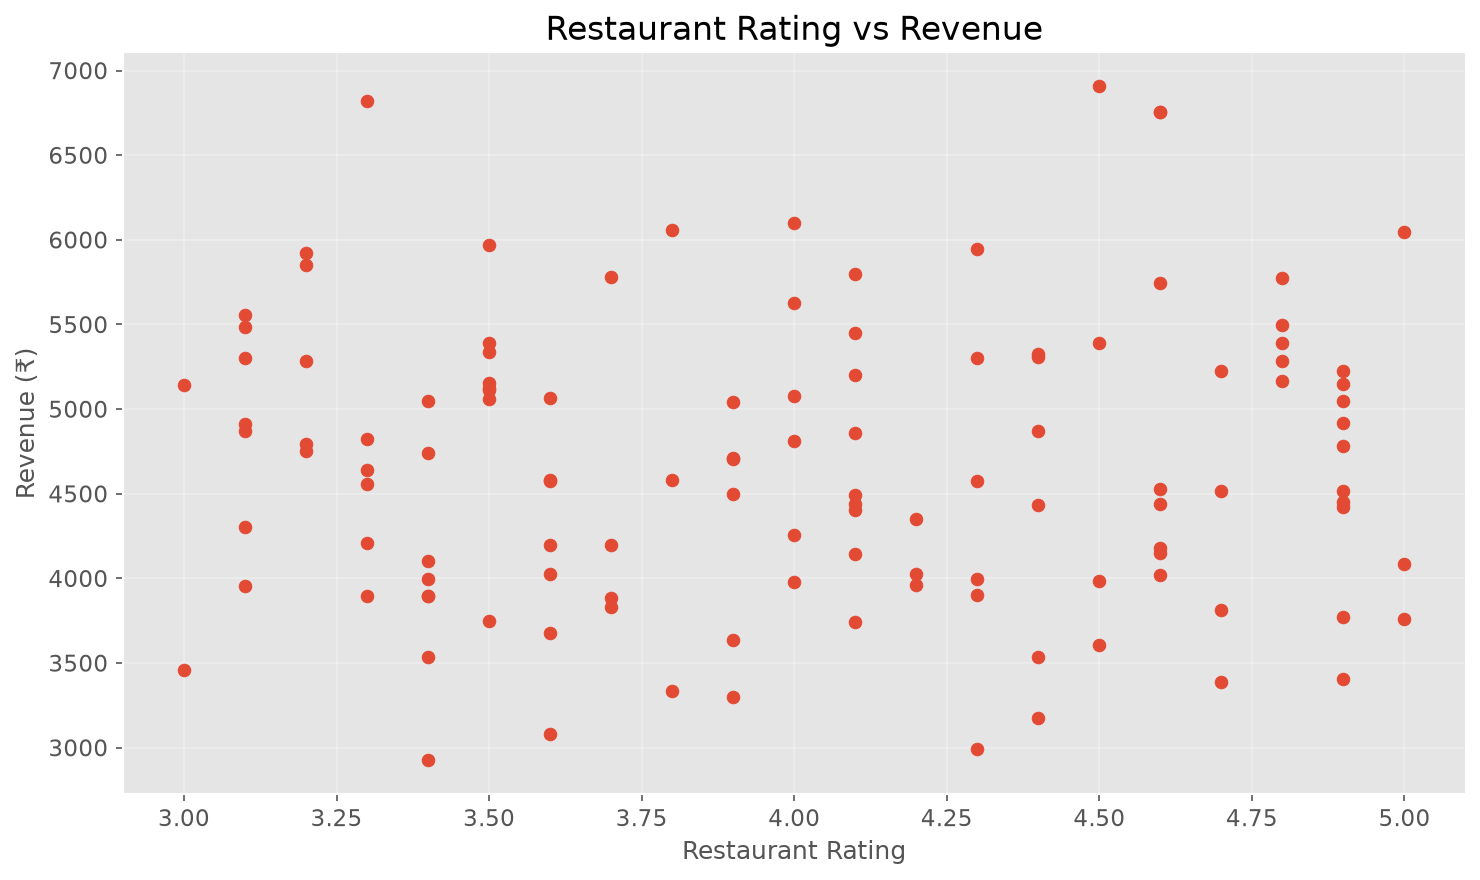

In [34]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rating_vs_revenue["rating"],
    rating_vs_revenue["revenue"]
)

plt.title("Restaurant Rating vs Revenue")
plt.xlabel("Restaurant Rating")
plt.ylabel("Revenue (₹)")
plt.grid(alpha =.3)
plt.tight_layout()

plt.savefig(
    output_dir / "rating_vs_revenue.png",
    dpi = 300,
    bbox_inches = "tight"
)

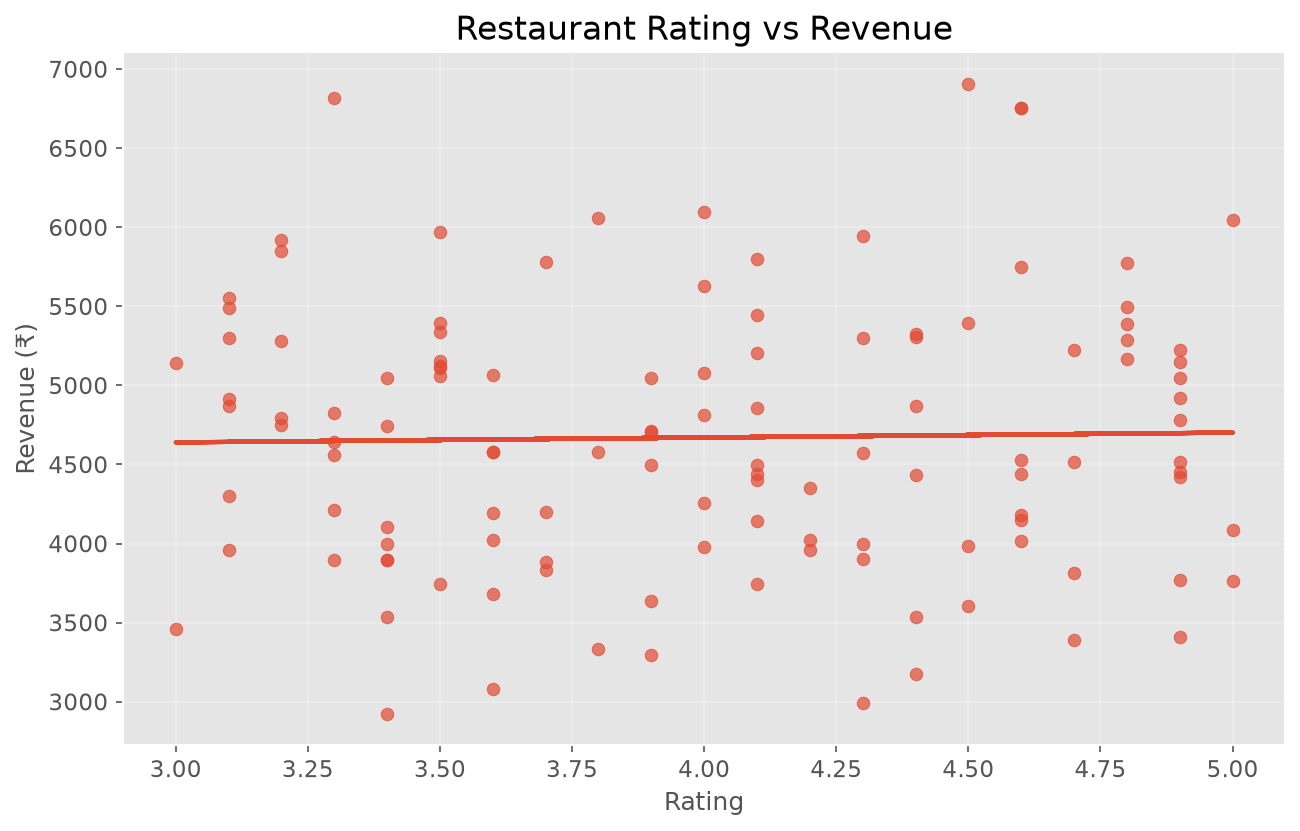

In [35]:
import numpy as np

z = np.polyfit(
    rating_vs_revenue["rating"],
    rating_vs_revenue["revenue"],
    1
)

p = np.poly1d(z)

plt.figure(figsize=(10,6))

plt.scatter(
    rating_vs_revenue["rating"],
    rating_vs_revenue["revenue"],
    alpha=0.7
)

plt.plot(
    rating_vs_revenue["rating"],
    p(rating_vs_revenue["rating"]),
    linewidth=2
)

plt.title("Restaurant Rating vs Revenue")
plt.xlabel("Rating")
plt.ylabel("Revenue (₹)")
plt.grid(alpha=.3)

# Executive Summary

This project analyzed food-delivery data using MySQL and Python to understand
revenue performance, customer behavior, restaurant performance, cuisine trends,
and operational patterns.

## Key Findings

- Total revenue generated: ₹560,509.15
- Average Order Value: ₹112.10
- 1,272 customers placed repeat orders
- Thai cuisine generated the highest revenue at ₹127,428.71
- Mexican cuisine had the highest average restaurant rating at 4.20
- R061 was the highest-revenue restaurant at ₹6,908.29
- Customer spending showed a right-skewed distribution, indicating a smaller
  group of high-value customers
- Delivered: 1,717 | Late: 1,671 | Cancelled: 1,612
- Restaurant ratings showed no strong relationship with restaurant revenue

## Business Recommendations

1. Investigate the drivers behind late and cancelled orders.
2. Build retention campaigns for high-value and repeat customers.
3. Study high-performing restaurants and replicate successful practices.
4. Promote highly rated but lower-revenue cuisines.
5. Use weekday demand patterns for staffing and promotional planning.

## Conclusion

The analysis demonstrates how SQL and Python can be combined to transform
relational transactional data into actionable business insights.